# RNAs que detienen TDP-43

**Una proteína prion-like se atasca dentro de las neuronas motoras. Y eso mata.** Eso pasa en la ELA — y en otras demencias. ¿Y si pudiéramos pegarle un fragmento corto de RNA para que no se atasque?

Eso intentaron en este paper. Probaron 17 RNAs distintos contra TDP-43 *in vitro* y midieron cuál evita la agregación con menos dosis. La potencia varía 9× entre el mejor y el peor. Y el patrón es más simple de lo que esperabas.

📄 **Paper:** [Science · DOI: 10.1126/science.adv3301](https://doi.org/10.1126/science.adv3301)
🎬 **Video:** [Pendiente]
📊 **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
🚀 [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-23-rna-chaperones-tdp-43/notebook.ipynb)

## El problema con TDP-43

TDP-43 es una proteína de unión a RNA que vive normalmente en el núcleo de las neuronas. Cuando funciona bien, regula qué partes del genoma se traducen. Cuando funciona mal, sale del núcleo, se acumula en el citoplasma y forma grumos sólidos — agregados que matan a la célula.

Esto se ve en el 97% de los casos de ELA (esclerosis lateral amiotrófica), en demencia frontotemporal, y empieza a aparecer en otros cuadros neurodegenerativos.

**La idea del paper:** TDP-43 tiene dos "manos" para agarrar RNA (los RRM, *RNA Recognition Motifs*). Si le damos un RNA corto que se les pegue bien, esas manos se quedan ocupadas y la proteína no se atasca. Funciona como una **chaperona**: previene la agregación manteniendo la proteína en su forma soluble.

¿Qué RNA es el mejor pegando? Veamos los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Cupo et al. (2026), Science · Datos: Table S1 (Supplementary)'
COLOR_NATURAL = '#2563EB'         # azul CaM — RNAs naturales
COLOR_ENGINEERED = '#DC2626'      # rojo — RNAs engineered
COLOR_CONTROL = '#BBBBBB'         # gris — controles
COLOR_REFERENCIA = '#D97706'      # amber — línea de referencia

# Imports + setup
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/rna_chaperones_tabla_s1.csv')
print(f'Total RNAs en el estudio: {len(df)}')
print(f'RNAs con IC50 medido: {df["ic50_uM"].notna().sum()}')
print(f'RNAs con KD medido: {df["kd_uM"].notna().sum()}')
print()
print('Distribución por tipo:')
print(df['rna_type'].value_counts().to_string())

Total RNAs en el estudio: 17
RNAs con IC50 medido: 15
RNAs con KD medido: 4

Distribución por tipo:
rna_type
natural            8
engineered         4
control            1
natural_short      1
control_pure_UG    1
G-quadruplex       1
control_short      1


## Aquí está.

Más repeticiones del motivo **UG**, más potente el RNA. Punto.

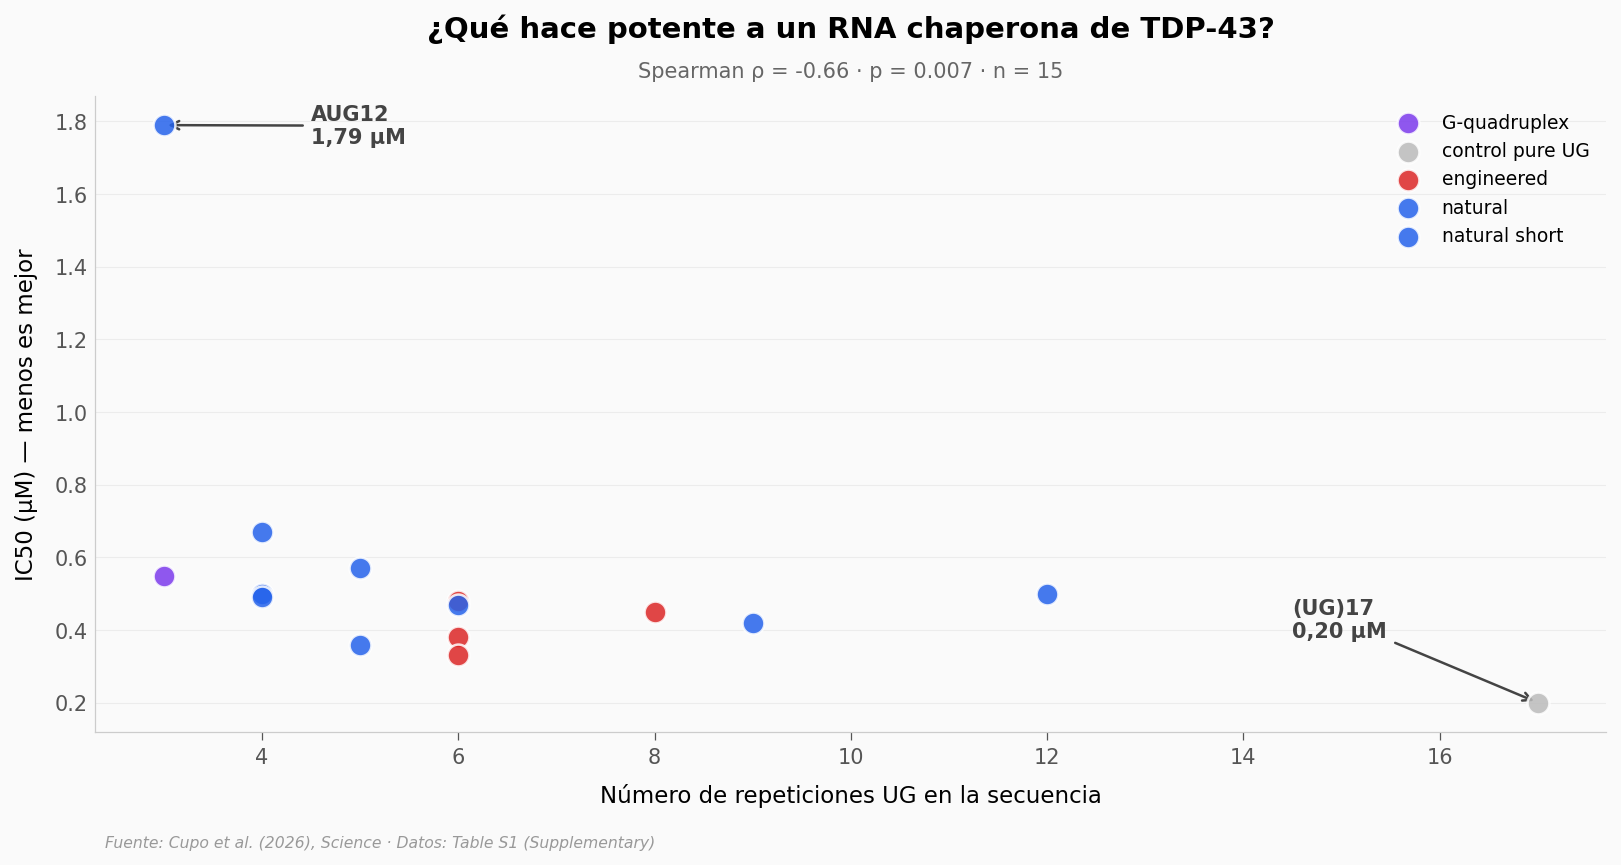

In [2]:
# Filtrar solo los que tienen IC50 medido
df_ic50 = df.dropna(subset=['ic50_uM']).copy()

# Calcular Spearman
rho, pval = stats.spearmanr(df_ic50['ug_count'], df_ic50['ic50_uM'])

fig, ax = plt.subplots(figsize=(13, 5.5))

# Colorear por tipo
color_map = {
    'natural': COLOR_NATURAL,
    'natural_short': COLOR_NATURAL,
    'engineered': COLOR_ENGINEERED,
    'control': COLOR_CONTROL,
    'control_pure_UG': COLOR_CONTROL,
    'control_short': COLOR_CONTROL,
    'G-quadruplex': '#7C3AED',
}

for tipo, grupo in df_ic50.groupby('rna_type'):
    ax.scatter(grupo['ug_count'], grupo['ic50_uM'],
               color=color_map.get(tipo, '#666'), s=110, alpha=0.85,
               edgecolors='white', linewidths=1.2, zorder=5,
               label=tipo.replace('_', ' '))

# Anotar el más potente: (UG)17
ug17 = df_ic50[df_ic50['rna_name'] == '(UG)17'].iloc[0]
ax.annotate('(UG)17\n0,20 µM',
            xy=(ug17['ug_count'], ug17['ic50_uM']),
            xytext=(ug17['ug_count'] - 2.5, ug17['ic50_uM'] + 0.18),
            fontsize=10, fontweight='bold', color='#444',
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# Anotar el menos potente: AUG12
aug12 = df_ic50[df_ic50['rna_name'] == 'AUG12'].iloc[0]
ax.annotate('AUG12\n1,79 µM',
            xy=(aug12['ug_count'], aug12['ic50_uM']),
            xytext=(aug12['ug_count'] + 1.5, aug12['ic50_uM'] - 0.05),
            fontsize=10, fontweight='bold', color='#444',
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

ax.set_xlabel('Número de repeticiones UG en la secuencia', fontsize=11)
ax.set_ylabel('IC50 (µM) — menos es mejor', fontsize=11)
ax.set_title(f'¿Qué hace potente a un RNA chaperona de TDP-43?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Spearman ρ = {rho:.2f} · p = {pval:.3f} · n = {len(df_ic50)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/01_ic50_vs_ug_count.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:**

- La línea baja de izquierda a derecha. Cuantas más unidades UG tiene un RNA, menor IC50 — o sea, hace falta menos cantidad para prevenir la agregación.
- (UG)17 (100% UG, 17 repeticiones) es el más potente con 0,20 µM. Es el extremo del experimento — un control sintético, no algo que exista en el cuerpo.
- AUG12, un RNA corto de solo 12 nucleótidos con 3 UGs, es el menos potente (1,79 µM). Sugiere que la longitud y el número de UGs importan.
- Los **engineered** (rojo) — RNAs que el equipo modificó para añadir más UGs — caen en la zona potente, aunque tienen UG_count similar a varios naturales.

El test estadístico confirma el patrón: **ρ = -0,66 con p = 0,007**. Es una correlación fuerte para una muestra pequeña.

Pero ojo: correlación no es predicción perfecta. ¿Y si lo que importa no es UG, sino el porcentaje de UG, o la estabilidad de la estructura secundaria? Verifiquemos.

## ¿Y si lo que importa es otra cosa?

El paper plantea tres hipótesis razonables para explicar la potencia:

1. **Número absoluto de UG** (cuántas veces aparece UG)
2. **Porcentaje UG** (densidad de UG en la secuencia)
3. **Estabilidad estructural** (qué tan plegado está el RNA, medido por ΔG)

Veámoslas lado a lado.

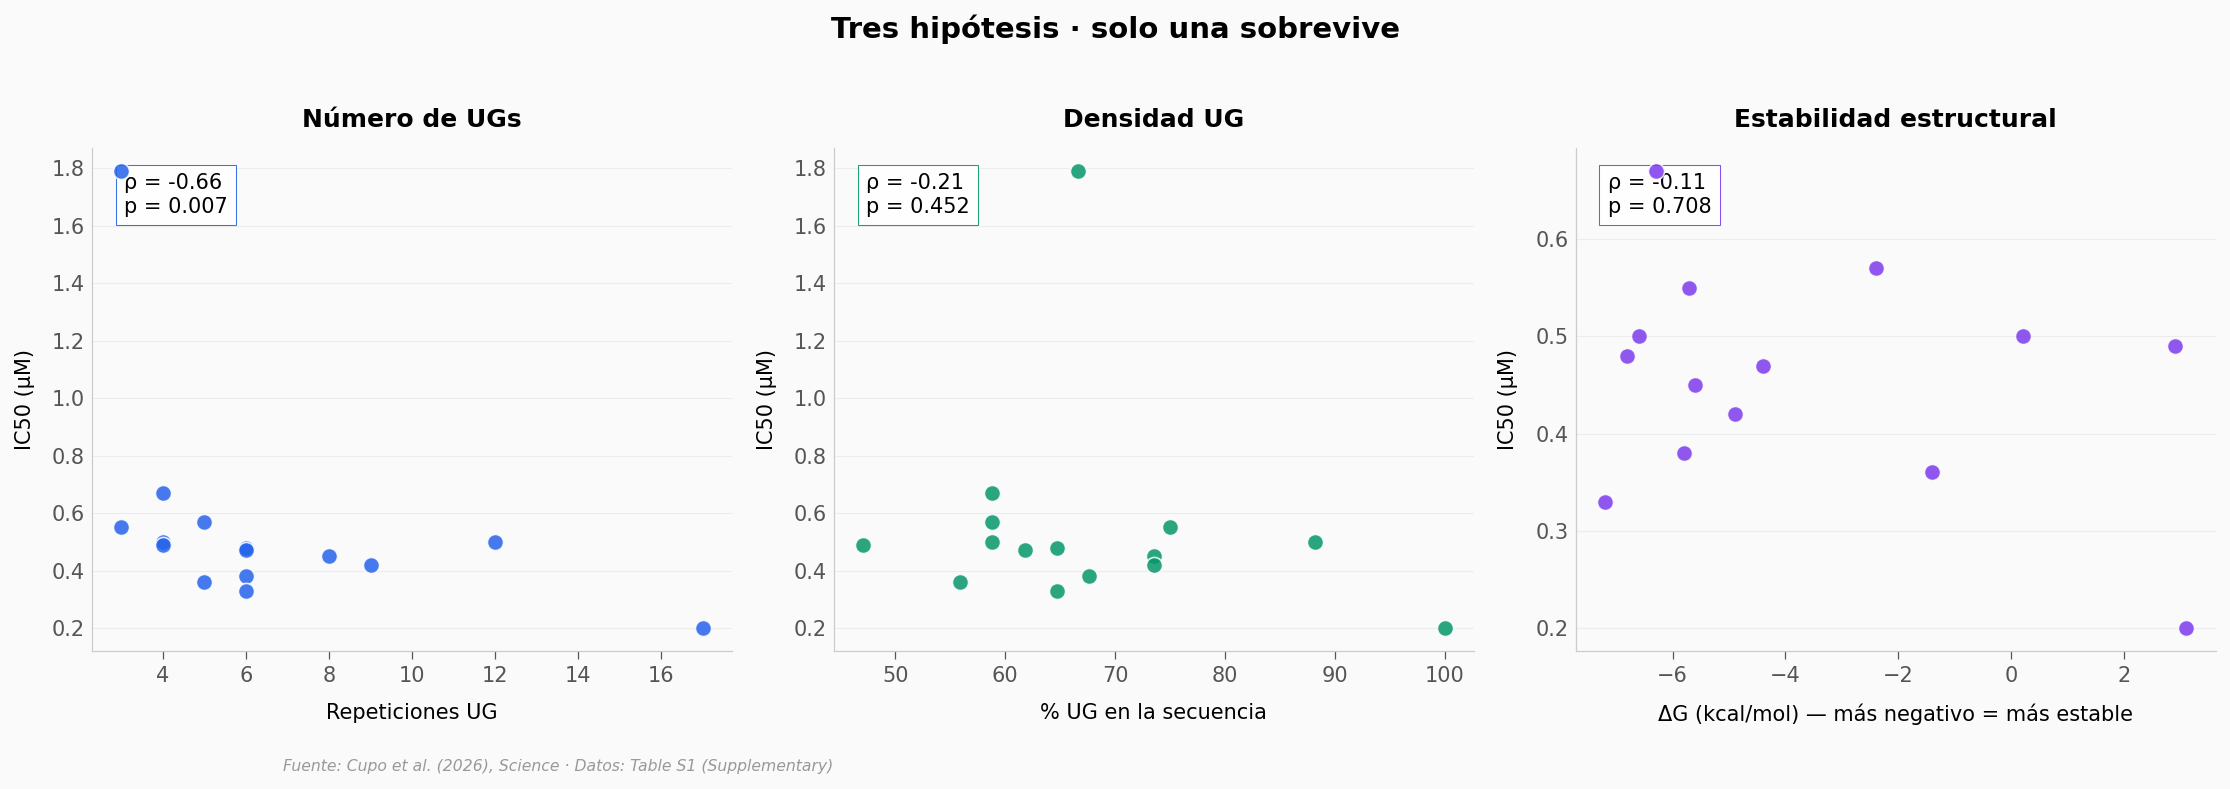

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# Panel 1: UG count
df_p1 = df.dropna(subset=['ic50_uM', 'ug_count'])
rho1, p1 = stats.spearmanr(df_p1['ug_count'], df_p1['ic50_uM'])
axes[0].scatter(df_p1['ug_count'], df_p1['ic50_uM'], color=COLOR_NATURAL,
                s=60, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5)
axes[0].set_xlabel('Repeticiones UG', fontsize=10)
axes[0].set_ylabel('IC50 (µM)', fontsize=10)
axes[0].set_title('Número de UGs', fontsize=12, fontweight='bold', pad=10)
axes[0].text(0.05, 0.95, f'ρ = {rho1:.2f}\np = {p1:.3f}',
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(facecolor='white', edgecolor='#2563EB', alpha=0.9))

# Panel 2: UG percent
df_p2 = df.dropna(subset=['ic50_uM', 'ug_percent'])
rho2, p2 = stats.spearmanr(df_p2['ug_percent'], df_p2['ic50_uM'])
axes[1].scatter(df_p2['ug_percent'], df_p2['ic50_uM'], color='#059669',
                s=60, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5)
axes[1].set_xlabel('% UG en la secuencia', fontsize=10)
axes[1].set_ylabel('IC50 (µM)', fontsize=10)
axes[1].set_title('Densidad UG', fontsize=12, fontweight='bold', pad=10)
axes[1].text(0.05, 0.95, f'ρ = {rho2:.2f}\np = {p2:.3f}',
             transform=axes[1].transAxes, fontsize=10, va='top',
             bbox=dict(facecolor='white', edgecolor='#059669', alpha=0.9))

# Panel 3: delta G
df_p3 = df.dropna(subset=['ic50_uM', 'delta_g_kcal_mol'])
rho3, p3 = stats.spearmanr(df_p3['delta_g_kcal_mol'], df_p3['ic50_uM'])
axes[2].scatter(df_p3['delta_g_kcal_mol'], df_p3['ic50_uM'], color='#7C3AED',
                s=60, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5)
axes[2].set_xlabel('ΔG (kcal/mol) — más negativo = más estable', fontsize=10)
axes[2].set_ylabel('IC50 (µM)', fontsize=10)
axes[2].set_title('Estabilidad estructural', fontsize=12, fontweight='bold', pad=10)
axes[2].text(0.05, 0.95, f'ρ = {rho3:.2f}\np = {p3:.3f}',
             transform=axes[2].transAxes, fontsize=10, va='top',
             bbox=dict(facecolor='white', edgecolor='#7C3AED', alpha=0.9))

plt.suptitle('Tres hipótesis · solo una sobrevive',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.tight_layout()
plt.savefig('figuras/02_tres_hipotesis.png', dpi=200, bbox_inches='tight')
plt.show()

**Solo una hipótesis pasa el filtro.**

- **Número de UGs** (panel izquierdo): ρ = -0,66 · p = 0,007. **Significativo.**
- **% UG** (panel central): ρ = -0,21 · p = 0,452. **No significativo.** La densidad por sí sola no predice nada.
- **ΔG** (panel derecho): ρ = -0,11 · p = 0,708. **No significativo.** Un RNA muy plegado no es mejor chaperona.

Lo que cuenta no es cuánto UG hay relativo al tamaño, ni qué tan rígido es el RNA — es cuántas unidades UG puede ofrecerle a TDP-43 como sitios de anclaje. Eso es coherente con el mecanismo molecular que propone el paper: los RRM de TDP-43 reconocen específicamente UG, y más UGs disponibles = más sitios de unión que mantienen ocupadas las "manos" de la proteína.

## ¿Pueden mejorar lo que la naturaleza nos da?

El equipo no se quedó con los RNAs naturales. Tomaron Clip34 — un RNA natural con afinidad razonable — y le inyectaron más UGs en distintas posiciones para crear versiones modificadas (engineered). ¿Funcionó?

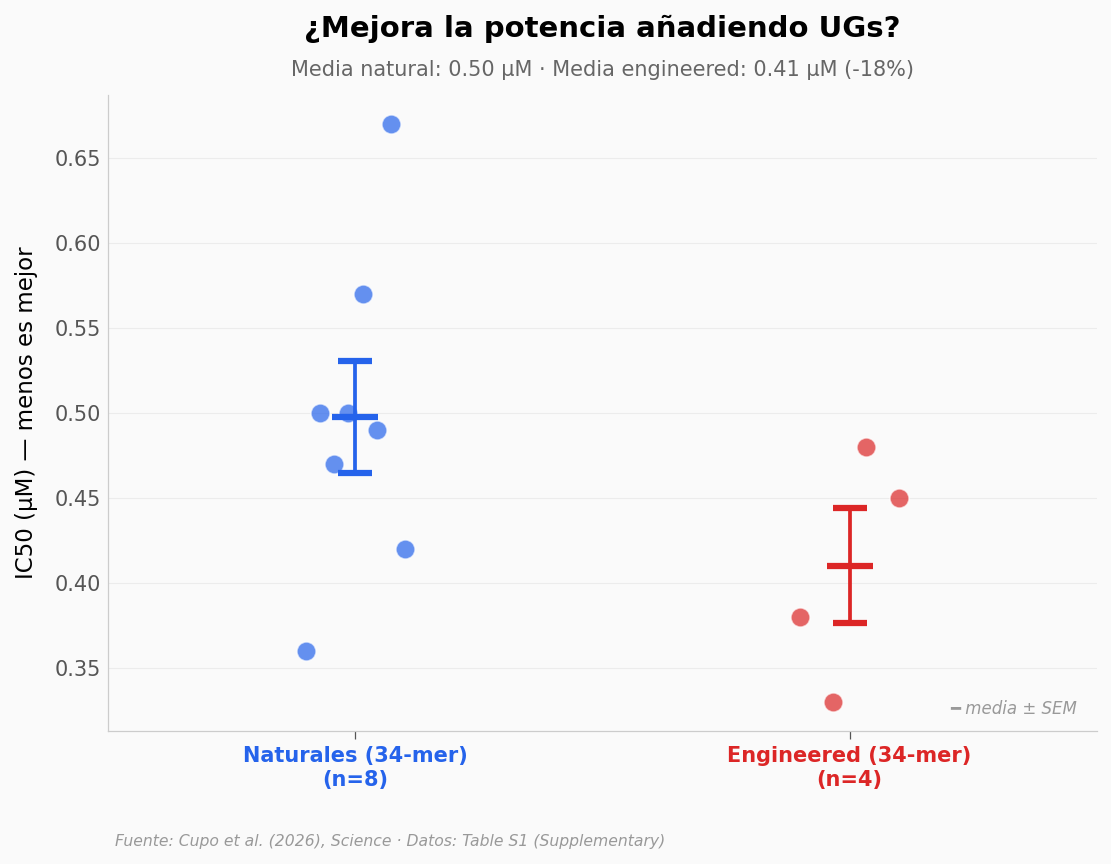

Naturales 34-mer (n=8): media 0.497 µM, SD 0.093
Engineered 34-mer (n=4): media 0.410 µM, SD 0.068
Diferencia: -17.6% (engineered son más potentes en promedio)

NOTA: comparación restringida a 34-mer (misma longitud). AUG12 (12-mer) queda fuera
porque su longitud distinta sesgaría la media — está en la gráfica hero con anotación propia.
n pequeño (8 vs 4): patrón observado, no diferencia estadísticamente significativa.


In [4]:
# Filtrar solo Clip34 y sus variantes engineered — comparación pareada justa.
# AUG12 (natural_short, 12-mer) NO se compara aquí: longitud distinta sesgaría la media.
natural = df[(df['rna_type'] == 'natural') & df['ic50_uM'].notna()]['ic50_uM'].values
engineered = df[(df['rna_type'] == 'engineered') & df['ic50_uM'].notna()]['ic50_uM'].values

# Diferencia relativa calculada dinámicamente
diff_pct = (engineered.mean() - natural.mean()) / natural.mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Jitter reproducible
np.random.seed(42)
positions = [0, 1]
groups = [('Naturales', natural, COLOR_NATURAL),
          ('Engineered', engineered, COLOR_ENGINEERED)]

for i, (label, vals, color) in enumerate(groups):
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=85, alpha=0.7,
               edgecolors='white', linewidths=0.8, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)

ax.set_xticks(positions)
ax.set_xticklabels([f'Naturales (34-mer)\n(n={len(natural)})',
                    f'Engineered (34-mer)\n(n={len(engineered)})'],
                   fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_NATURAL, COLOR_ENGINEERED]):
    tick.set_color(color)

ax.set_ylabel('IC50 (µM) — menos es mejor', fontsize=11)
ax.set_title('¿Mejora la potencia añadiendo UGs?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Media natural: {natural.mean():.2f} µM · Media engineered: {engineered.mean():.2f} µM ({diff_pct:+.0f}%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax.set_xlim(-0.5, 1.5)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/03_engineered_vs_natural.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Naturales 34-mer (n={len(natural)}): media {natural.mean():.3f} µM, SD {natural.std(ddof=1):.3f}')
print(f'Engineered 34-mer (n={len(engineered)}): media {engineered.mean():.3f} µM, SD {engineered.std(ddof=1):.3f}')
print(f'Diferencia: {diff_pct:+.1f}% (engineered son más potentes en promedio)')
print()
print('NOTA: comparación restringida a 34-mer (misma longitud). AUG12 (12-mer) queda fuera')
print('porque su longitud distinta sesgaría la media — está en la gráfica hero con anotación propia.')
print('n pequeño (8 vs 4): patrón observado, no diferencia estadísticamente significativa.')

## ¿Qué tan especial es (UG)17?

(UG)17 es el más potente del set con IC50 = 0,20 µM. Pero ¿qué tan lejos está del resto?

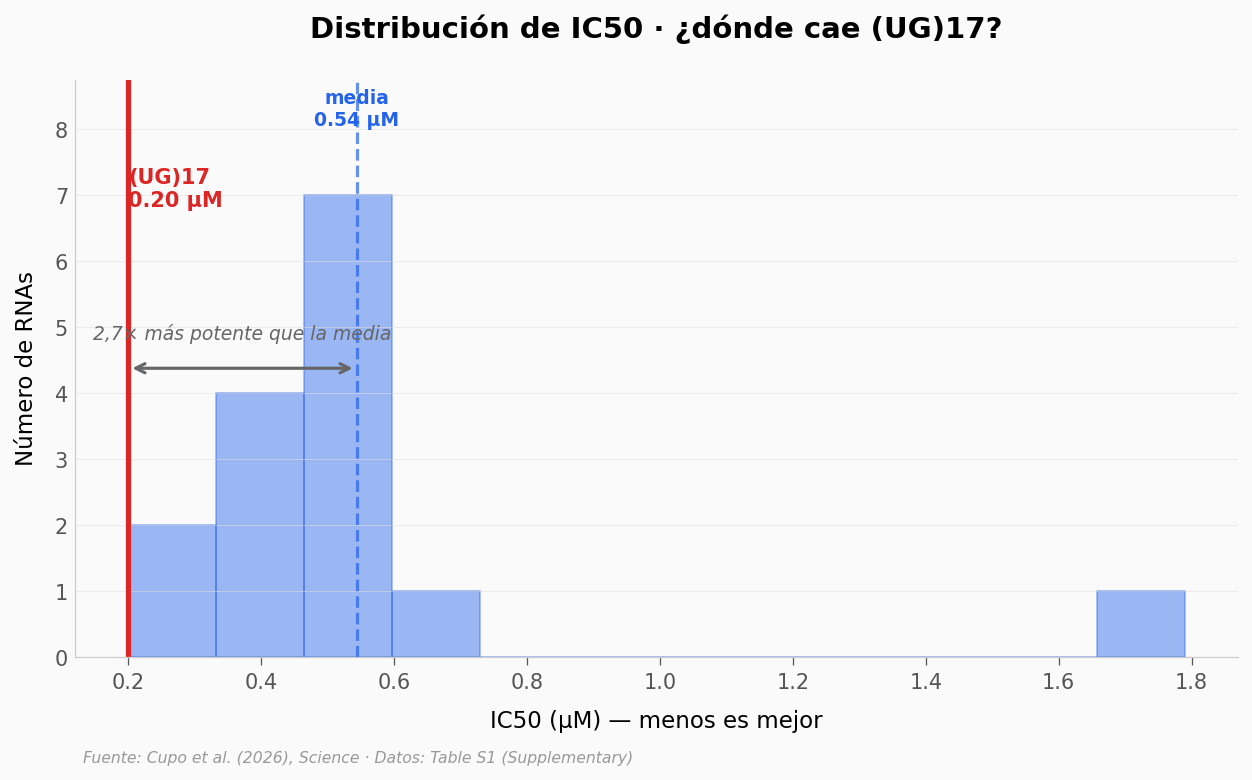

In [5]:
ic50_vals = df_ic50['ic50_uM'].values
ug17_val = 0.20

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(ic50_vals, bins=12, color=COLOR_NATURAL, alpha=0.45,
                            edgecolor=COLOR_NATURAL, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

media = ic50_vals.mean()
ax.axvline(x=media, color=COLOR_NATURAL, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(media, y_max * 0.92, f'media\n{media:.2f} µM', color=COLOR_NATURAL,
        fontsize=9, ha='center', fontweight='bold')

ax.axvline(x=ug17_val, color=COLOR_ENGINEERED, linewidth=2.5)
ax.text(ug17_val, y_max * 0.78, f'(UG)17\n{ug17_val:.2f} µM',
        color=COLOR_ENGINEERED, fontsize=10, ha='left', fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(ug17_val, y_max * 0.5), xytext=(media, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ug17_val + media) / 2, y_max * 0.55, f'2,7× más potente que la media',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('IC50 (µM) — menos es mejor', fontsize=11)
ax.set_ylabel('Número de RNAs', fontsize=11)
ax.set_title('Distribución de IC50 · ¿dónde cae (UG)17?',
             fontsize=14, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/04_histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El número de UGs predice la potencia chaperona | ✅ Sí | Spearman ρ = -0,66, p = 0,007, n = 15. Correlación fuerte y estadísticamente significativa. |
| El % UG y la estabilidad estructural NO predicen la potencia | ✅ Sí | ρ = -0,21 (p = 0,452) y ρ = -0,11 (p = 0,708) respectivamente. No alcanzan significancia. |
| Los RNAs engineered son más potentes que los naturales | ⚠️ Parcial | Media natural 0,50 µM vs engineered 0,41 µM (−18%, Cohen's d = -1,01, Mann-Whitney U p = 0,106). Tamaño de efecto grande pero n pequeño (4 vs 8) impide significancia estadística; el paper no reporta test de hipótesis para esta comparación. |
| (UG)17 es el más potente del set | ✅ Sí | IC50 = 0,20 µM, 2,4× mejor que la media del set. Es el extremo de un experimento — control sintético, no candidato terapéutico directo. |

> **Limitaciones del análisis:**
> - Dataset = Tabla S1 del paper (17 RNAs, solo IC50 + KD reportados; las gráficas no incluyen los experimentos en ratones ni neuronas humanas del paper).
> - Spearman con n = 15 tiene poco poder para detectar correlaciones débiles. Una correlación que aparece "no significativa" aquí podría serlo en un set mayor.
> - El paper hace experimentos *in vitro*, en optogenetic models, en neuronas de pacientes y en ratones. Este notebook se queda en la capa más básica (IC50 de unión *in vitro*); las afirmaciones de eficacia terapéutica *in vivo* vienen de otras tablas/figuras.
> - n natural = 8, n engineered = 4. La comparación de medias no debe interpretarse como evidencia fuerte de superioridad de los engineered.

## Ahora tú

1. **¿Y si separamos por longitud?** Los RNAs de 34 nucleótidos podrían comportarse distinto de los cortos (12-13 nt). Filtra `df` por `length_nt` y vuelve a calcular las correlaciones.
2. **¿KD y IC50 cuentan la misma historia?** Solo 4 RNAs tienen ambos medidos. Compara `kd_uM` vs `ic50_uM` para ver si son intercambiables como métrica de afinidad.
3. **¿El mejor natural se acerca al mejor engineered?** Identifica el RNA natural con menor IC50 y comparalo contra el mejor engineered. Calcula el ratio.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Comparación KD vs IC50 (solo 4 RNAs tienen ambos)
df_both = df.dropna(subset=['ic50_uM', 'kd_uM']).copy()
print(f'RNAs con ambos medidos: {len(df_both)}')
print()
print(df_both[['rna_name', 'ic50_uM', 'kd_uM', 'rna_type']].to_string(index=False))
print()
if len(df_both) >= 3:
    rho_metricas, p_metricas = stats.spearmanr(df_both['kd_uM'], df_both['ic50_uM'])
    print(f'Spearman KD vs IC50: ρ = {rho_metricas:.2f}, p = {p_metricas:.3f}')
    print('Si ρ es alto y p bajo: las dos métricas cuentan la misma historia.')

RNAs con ambos medidos: 4

    rna_name  ic50_uM  kd_uM   rna_type
      Clip34     0.50   0.49    natural
  Clip34_UG6     0.45   0.27 engineered
      SATIII     0.49   0.53    natural
Malat1_start     0.36   0.56    natural

Spearman KD vs IC50: ρ = -0.40, p = 0.600
Si ρ es alto y p bajo: las dos métricas cuentan la misma historia.


## Fuentes

**Paper**: [Short RNA chaperones promote aggregation-resistant TDP-43 conformers to mitigate neurodegeneration](https://doi.org/10.1126/science.adv3301)  
*Science, 2026-05-07*

**Supplementary Material**: [Supplementary Materials (Table S1: RNA oligonucleotides utilized in this study)](https://www.science.org/doi/suppl/10.1126/science.adv3301/suppl_file/science.adv3301_sm.pdf)  
*Tabla S1 contiene los 17 RNAs con sus parámetros biofísicos*

**Dataset canónico**: [Data from: Short RNA chaperones promote aggregation-resistant TDP-43 conformers to mitigate neurodegeneration](https://doi.org/10.5061/dryad.9s4mw6mx4)  
*Dryad repository — datos crudos del paper*

*17 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad:**
- Notebook + datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-23-rna-chaperones-tdp-43)
- Datos crudos: Table S1 del Supplementary del paper (publicado bajo licencia Science / AAAS).
- Análisis hecho con `pandas`, `scipy.stats`, `matplotlib`. Sin secretos ni datos privados.

**Cita:** Cupo C., Lipke E., Sun L. et al. *Short RNA chaperones promote aggregation-resistant TDP-43 conformers to mitigate neurodegeneration*. **Science** (2026). [doi:10.1126/science.adv3301](https://doi.org/10.1126/science.adv3301)

---

*Ciencia a Mordiscos · El Lab — donde el video se vuelve verificable.*